In [9]:
from pathlib import Path
import json
import os
import random
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

CANDIDATE_BASE_DIRS = [Path.cwd(), Path.cwd() / 'preprocessing']
BASE_DIR = next((p for p in CANDIDATE_BASE_DIRS if (p / 'guard_bed_pressure_dataset.csv').exists()), Path.cwd())

DATA_PATH = BASE_DIR / 'guard_bed_pressure_dataset.csv'
MODEL_DIR = BASE_DIR / 'guard_bed_rnn_models'
BUNDLE_PATH = BASE_DIR / 'guard_bed_rnn_bundle.joblib'
METRICS_PATH = BASE_DIR / 'guard_bed_rnn_metrics.csv'

RANDOM_STATE = 42
TEST_SIZE = 0.20
VALID_SIZE = 0.20
EPOCHS = 40
BATCH_SIZE = 32

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

plt.style.use('seaborn-v0_8-whitegrid')
MODEL_DIR.mkdir(exist_ok=True)

try:
    tf.config.threading.set_intra_op_parallelism_threads(1)
    tf.config.threading.set_inter_op_parallelism_threads(1)
except RuntimeError:
    pass

print('BASE_DIR =', BASE_DIR.resolve())
print('DATA_PATH =', DATA_PATH.resolve())


BASE_DIR = /content
DATA_PATH = /content/guard_bed_pressure_dataset.csv


In [10]:
df = pd.read_csv(DATA_PATH)
print('shape =', df.shape)
display(df.head())

target_cols = ['deltaP_future_kPa', 'friction_factor_future']
forbidden_input_cols = ['d_deltaP_dt_kPa_h']

feature_cols = [
    'bed_length_m',
    'bed_diameter_m',
    'particle_diameter_m',
    'bed_porosity_0',
    'particle_sphericity',
    'flow_mol_s',
    'T_in_C',
    'P_in_kPa',
    'RH_in',
    'y_CO2_in',
    'y_N2_in',
    'y_O2_in',
    'y_H2O_in',
    'PM_inlet_mg_m3',
    'mist_inlet_mg_m3',
    'filter_age_h_0',
    'cleaning_count_0',
    'time_since_last_cleaning_h_0',
    'cleaning_interval_h',
    'pulse_intensity',
    'drainage_rate_1_h',
    'pm_capture_coeff_1_s',
    'mist_capture_coeff_1_s',
    'humidification_factor',
    'time_h',
    'P_out_kPa',
    'deltaP_kPa',
    'friction_factor',
    'Re_particle',
    'flow_actual_m3_s',
    'superficial_velocity_m_s',
    'gas_density_kg_m3',
    'gas_viscosity_Pa_s',
    'outlet_PM_mg_m3',
    'outlet_mist_mg_m3',
    'avg_porosity',
    'min_porosity',
    'avg_solid_load_kg_m3',
    'avg_liquid_hold_kg_m3',
    'max_solid_load_kg_m3',
    'max_liquid_hold_kg_m3',
    'operating_time_h',
    'filter_age_h',
    'cleaning_count',
    'time_since_last_cleaning_h',
]

required_cols = ['sample_id'] + feature_cols + target_cols
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}')

leakage_cols_present = [c for c in forbidden_input_cols if c in feature_cols]
if leakage_cols_present:
    raise ValueError(f'Leakage columns cannot be used as inputs: {leakage_cols_present}')

model_df = (
    df[required_cols]
    .dropna()
    .sort_values(['sample_id', 'time_h'])
    .reset_index(drop=True)
    .copy()
)

seq_lengths = model_df.groupby('sample_id').size()
print('usable rows =', len(model_df))
print('n_sequences =', seq_lengths.size)
print('seq_len min/max =', seq_lengths.min(), seq_lengths.max())
print('num_features =', len(feature_cols))
display(model_df[['sample_id', 'time_h', 'deltaP_kPa', 'deltaP_future_kPa', 'P_out_kPa']].head(10))


shape = (1320000, 49)


,sample_id,bed_length_m,bed_diameter_m,particle_diameter_m,bed_porosity_0,particle_sphericity,flow_mol_s,T_in_C,P_in_kPa,RH_in,...,avg_liquid_hold_kg_m3,max_solid_load_kg_m3,max_liquid_hold_kg_m3,operating_time_h,filter_age_h,cleaning_count,time_since_last_cleaning_h,deltaP_future_kPa,friction_factor_future,d_deltaP_dt_kPa_h
0,1,1.306723,2.590191,0.009393,0.391323,0.853238,722.643536,51.457717,100.796874,0.818999,...,0.004335,0.010915,0.004335,0.016667,229.971984,6.0,2.437439,60.796874,15.214117,0.0
1,1,1.306723,2.590191,0.009393,0.391323,0.853238,722.643536,51.457717,100.796874,0.818999,...,0.008646,0.021830,0.008646,0.033333,229.988650,6.0,2.454106,60.796874,15.213461,0.0
2,1,1.306723,2.590191,0.009393,0.391323,0.853238,722.643536,51.457717,100.796874,0.818999,...,0.012932,0.032745,0.012932,0.050000,230.005317,6.0,2.470773,60.796874,15.212805,0.0
3,1,1.306723,2.590191,0.009393,0.391323,0.853238,722.643536,51.457717,100.796874,0.818999,...,0.017195,0.043660,0.017195,0.066667,230.021984,6.0,2.487439,60.796874,15.212151,0.0
4,1,1.306723,2.590191,0.009393,0.391323,0.853238,722.643536,51.457717,100.796874,0.818999,...,0.021435,0.054575,0.021435,0.083333,230.038650,6.0,2.504106,60.796874,15.211497,0.0


usable rows = 1320000
n_sequences = 2000
seq_len min/max = 660 660
num_features = 45


,sample_id,time_h,deltaP_kPa,deltaP_future_kPa,P_out_kPa
0,1,0.000000,60.796874,60.796874,40.0
1,1,0.016667,60.796874,60.796874,40.0
2,1,0.033333,60.796874,60.796874,40.0
3,1,0.050000,60.796874,60.796874,40.0
4,1,0.066667,60.796874,60.796874,40.0
5,1,0.083333,60.796874,60.796874,40.0
6,1,0.100000,60.796874,60.796874,40.0
7,1,0.116667,60.796874,60.796874,40.0
8,1,0.133333,60.796874,60.796874,40.0
9,1,0.150000,60.796874,60.796874,40.0


In [11]:
from collections import Counter
import numpy as np
from sklearn.model_selection import train_test_split

EXPECTED_LEN = 660

sample_ids = model_df['sample_id']
unique_ids = np.array(sorted(sample_ids.unique()))

sequence_frames = {
    sample_id: seq.sort_values('time_h').reset_index(drop=True)
    for sample_id, seq in model_df.groupby('sample_id', sort=True)
}

# 길이 확인
length_counter = Counter(len(seq) for seq in sequence_frames.values())
print("sequence length counts:", length_counter)

# 길이가 660인 sample_id만 사용
valid_length_ids = np.array([
    sample_id
    for sample_id in unique_ids
    if len(sequence_frames[sample_id]) == EXPECTED_LEN
])

removed_ids = np.array([
    sample_id
    for sample_id in unique_ids
    if len(sequence_frames[sample_id]) != EXPECTED_LEN
])

print("usable sample count:", len(valid_length_ids))
print("removed sample count:", len(removed_ids))
print("removed length counts:", Counter(len(sequence_frames[sid]) for sid in removed_ids))

# split은 필터링 이후에 수행
train_ids, test_ids = train_test_split(
    valid_length_ids,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

train_ids, valid_ids = train_test_split(
    train_ids,
    test_size=VALID_SIZE,
    random_state=RANDOM_STATE
)

def build_sequence_arrays(sequence_frames, ids, feature_cols, target_cols):
    x_list = []
    y_list = []
    time_list = []

    for sample_id in ids:
        seq = sequence_frames[sample_id]

        x_list.append(seq[feature_cols].to_numpy(dtype=np.float32))
        y_list.append(seq[target_cols].to_numpy(dtype=np.float32))
        time_list.append(seq['time_h'].to_numpy(dtype=np.float32))

    return (
        np.stack(x_list).astype(np.float32),
        np.stack(y_list).astype(np.float32),
        np.stack(time_list).astype(np.float32)
    )

X_train, y_train, t_train = build_sequence_arrays(
    sequence_frames, train_ids, feature_cols, target_cols
)

X_valid, y_valid, t_valid = build_sequence_arrays(
    sequence_frames, valid_ids, feature_cols, target_cols
)

X_test, y_test, t_test = build_sequence_arrays(
    sequence_frames, test_ids, feature_cols, target_cols
)

sequence_length = X_train.shape[1]
num_features = X_train.shape[2]
num_targets = y_train.shape[2]

print('train:', X_train.shape, y_train.shape)
print('valid:', X_valid.shape, y_valid.shape)
print('test :', X_test.shape, y_test.shape)
print('sequence_length:', sequence_length)
print('num_features:', num_features)
print('num_targets:', num_targets)

sequence length counts: Counter({660: 2000})
usable sample count: 2000
removed sample count: 0
removed length counts: Counter()
train: (1280, 660, 45) (1280, 660, 2)
valid: (320, 660, 45) (320, 660, 2)
test : (400, 660, 45) (400, 660, 2)
sequence_length: 660
num_features: 45
num_targets: 2


In [12]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, num_features)
X_valid_2d = X_valid.reshape(-1, num_features)
X_test_2d = X_test.reshape(-1, num_features)

y_train_2d = y_train.reshape(-1, num_targets)
y_valid_2d = y_valid.reshape(-1, num_targets)
y_test_2d = y_test.reshape(-1, num_targets)

X_train_scaled = x_scaler.fit_transform(X_train_2d).reshape(X_train.shape).astype(np.float32)
X_valid_scaled = x_scaler.transform(X_valid_2d).reshape(X_valid.shape).astype(np.float32)
X_test_scaled = x_scaler.transform(X_test_2d).reshape(X_test.shape).astype(np.float32)

y_train_scaled = y_scaler.fit_transform(y_train_2d).reshape(y_train.shape).astype(np.float32)
y_valid_scaled = y_scaler.transform(y_valid_2d).reshape(y_valid.shape).astype(np.float32)
y_test_scaled = y_scaler.transform(y_test_2d).reshape(y_test.shape).astype(np.float32)

def inverse_targets(y_scaled):
    flat = y_scaled.reshape(-1, num_targets)
    return y_scaler.inverse_transform(flat).reshape(y_scaled.shape)

print('scaled train mean (x) =', float(X_train_scaled.mean()))
print('scaled train mean (y) =', float(y_train_scaled.mean()))


scaled train mean (x) = 5.514934731110088e-09
scaled train mean (y) = -2.510619934170677e-09


In [13]:
def build_sequence_model(model_kind, input_shape, output_dim):
    rnn_layer = layers.LSTM if model_kind.upper() == 'LSTM' else layers.GRU

    inputs = keras.Input(shape=input_shape, name='sequence_input')
    x = layers.GaussianNoise(0.01)(inputs)
    x = rnn_layer(96, return_sequences=True, dropout=0.10, recurrent_dropout=0.05)(x)
    x = layers.LayerNormalization()(x)
    x = rnn_layer(64, return_sequences=True, dropout=0.10, recurrent_dropout=0.05)(x)
    x = layers.TimeDistributed(layers.Dense(64, activation='relu'))(x)
    outputs = layers.TimeDistributed(layers.Dense(output_dim), name='future_targets')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name=f'{model_kind.lower()}_surrogate')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=[keras.metrics.MeanAbsoluteError(name='mae')],
    )
    return model

def regression_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-9))) * 100.0
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'mape_pct': mape}


In [14]:
models = {}
histories = {}
pred_store = {}
metrics_rows = []

for model_kind in ['LSTM', 'GRU']:
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    model = build_sequence_model(model_kind, (sequence_length, num_features), num_targets)
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-5,
        ),
    ]

    history = model.fit(
        X_train_scaled,
        y_train_scaled,
        validation_data=(X_valid_scaled, y_valid_scaled),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=callbacks,
    )

    models[model_kind] = model
    histories[model_kind] = pd.DataFrame(history.history)
    pred_store[model_kind] = {}

    for split_name, X_split, y_split in [
        ('valid', X_valid_scaled, y_valid),
        ('test', X_test_scaled, y_test),
    ]:
        pred_scaled = model.predict(X_split, verbose=0)
        pred = inverse_targets(pred_scaled)
        pred_store[model_kind][split_name] = pred

        for target_idx, target in enumerate(target_cols):
            stats = regression_metrics(
                y_split[:, :, target_idx].ravel(),
                pred[:, :, target_idx].ravel(),
            )
            stats.update({'model': model_kind, 'split': split_name, 'target': target})
            metrics_rows.append(stats)

metrics_df = pd.DataFrame(metrics_rows).sort_values(['target', 'split', 'rmse']).reset_index(drop=True)
display(metrics_df)


Epoch 1/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - loss: 0.3491 - mae: 0.4310 - val_loss: 0.1009 - val_mae: 0.2303 - learning_rate: 0.0010
Epoch 2/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - loss: 0.1213 - mae: 0.2424 - val_loss: 0.0660 - val_mae: 0.1893 - learning_rate: 0.0010
Epoch 3/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - loss: 0.0793 - mae: 0.2067 - val_loss: 0.0552 - val_mae: 0.1766 - learning_rate: 0.0010
Epoch 4/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - loss: 0.0676 - mae: 0.1902 - val_loss: 0.0480 - val_mae: 0.1629 - learning_rate: 0.0010
Epoch 5/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - loss: 0.0612 - mae: 0.1792 - val_loss: 0.0468 - val_mae: 0.1578 - learning_rate: 0.0010
Epoch 6/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - loss: 0.0571 - mae: 0.1735 - val_loss: 0.0403 - val_mae: 0.1485 - learning_rate: 0.0010
Epoch 7/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - loss: 0.0504 - mae: 0.1606 - val_loss: 0.0365 - val_mae: 0.1407 - learning_rate: 0.0010
Epoch 8/40
40

,rmse,mae,r2,mape_pct,model,split,target
0,1.542813,1.178159,0.993658,5.594483,GRU,test,deltaP_future_kPa
1,1.595058,1.201942,0.993222,5.615628,LSTM,test,deltaP_future_kPa
2,1.598155,1.169523,0.993054,6.037478,LSTM,valid,deltaP_future_kPa
3,1.721875,1.289533,0.991937,6.650923,GRU,valid,deltaP_future_kPa
4,0.346943,0.250029,0.985700,1.963180,LSTM,test,friction_factor_future
5,0.365548,0.262378,0.984125,2.021441,GRU,test,friction_factor_future
6,0.357226,0.256798,0.986502,2.133693,GRU,valid,friction_factor_future
7,0.392413,0.258606,0.983712,2.175384,LSTM,valid,friction_factor_future


best test model for deltaP_future_kPa = GRU


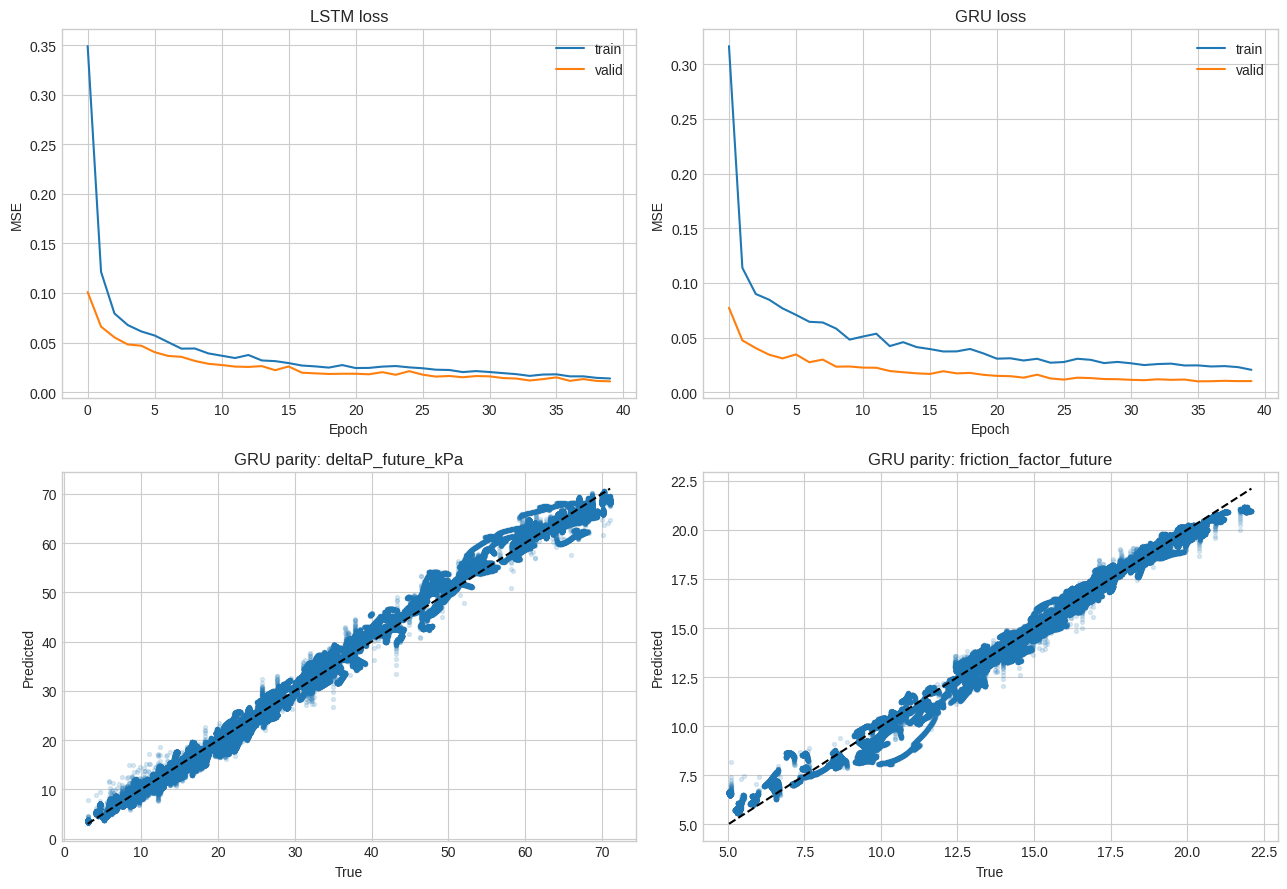

In [15]:
best_model_kind = (
    metrics_df.loc[metrics_df['target'] == 'deltaP_future_kPa']
    .query("split == 'test'")
    .sort_values('rmse')
    .iloc[0]['model']
)
print('best test model for deltaP_future_kPa =', best_model_kind)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, model_kind in zip(axes[0], ['LSTM', 'GRU']):
    history_df = histories[model_kind]
    ax.plot(history_df['loss'], label='train')
    ax.plot(history_df['val_loss'], label='valid')
    ax.set_title(f'{model_kind} loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()

for ax, target_idx in zip(axes[1], range(len(target_cols))):
    target = target_cols[target_idx]
    y_true = y_test[:, :, target_idx].ravel()
    y_pred = pred_store[best_model_kind]['test'][:, :, target_idx].ravel()
    ax.scatter(y_true, y_pred, s=8, alpha=0.15)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], color='black', linestyle='--')
    ax.set_title(f'{best_model_kind} parity: {target}')
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')

fig.tight_layout()


In [16]:
for model_kind, model in models.items():
    model.save(MODEL_DIR / f'{model_kind.lower()}_surrogate.keras')

bundle = {
    'feature_cols': feature_cols,
    'target_cols': target_cols,
    'forbidden_input_cols': forbidden_input_cols,
    'sequence_length': sequence_length,
    'train_ids': train_ids.tolist(),
    'valid_ids': valid_ids.tolist(),
    'test_ids': test_ids.tolist(),
    'x_scaler': x_scaler,
    'y_scaler': y_scaler,
    'metrics_df': metrics_df,
    'history': {k: v.to_dict(orient='list') for k, v in histories.items()},
    'data_path': str(DATA_PATH),
    'model_dir': str(MODEL_DIR),
}

joblib.dump(bundle, BUNDLE_PATH)
metrics_df.to_csv(METRICS_PATH, index=False)

summary = {
    'saved_models': sorted(str(p) for p in MODEL_DIR.glob('*.keras')),
    'bundle_path': str(BUNDLE_PATH),
    'metrics_path': str(METRICS_PATH),
}
print(json.dumps(summary, indent=2))


{
  "saved_models": [
    "/content/guard_bed_rnn_models/gru_surrogate.keras",
    "/content/guard_bed_rnn_models/lstm_surrogate.keras"
  ],
  "bundle_path": "/content/guard_bed_rnn_bundle.joblib",
  "metrics_path": "/content/guard_bed_rnn_metrics.csv"
}


In [17]:
import joblib

bundle = joblib.load('/content/guard_bed_rnn_bundle.joblib')

print(bundle.keys())

dict_keys(['feature_cols', 'target_cols', 'forbidden_input_cols', 'sequence_length', 'train_ids', 'valid_ids', 'test_ids', 'x_scaler', 'y_scaler', 'metrics_df', 'history', 'data_path', 'model_dir'])
